### EDA & Feature Engineering Using Flight Price Prediction

##### DATASET
Dataset contains information about flight booking options from the website Easemytrip for flight travel between India's top 6 metro cities. There are 300261 datapoints and 11 features in the cleaned dataset.

##### FEATURES
The various features of the cleaned dataset are explained below:
1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.
2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.
3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.
4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.
5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.
6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.
7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.
8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.
9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.
10) Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.
11) Price: Target variable stores information of the ticket price.

In [265]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

In [266]:
#dataset
flight_df = pd.read_excel("flight_price.xlsx")
flight_df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [267]:
flight_df.shape

(10683, 11)

In [268]:
flight_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [269]:
flight_df = flight_df[~flight_df.duplicated()]
flight_df.shape

(10463, 11)

In [270]:
flight_df.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

<Axes: xlabel='Airline'>

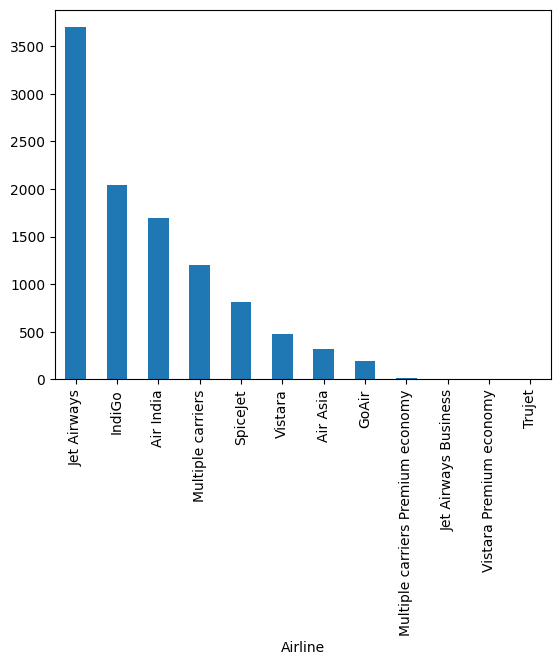

In [271]:
flight_df['Airline'].value_counts().plot(kind='bar')

In [272]:
#Extracting features from existing features
flight_df['Day']=flight_df['Date_of_Journey'].str.split("/").str[0].astype(int)
flight_df['Month']=flight_df['Date_of_Journey'].str.split("/").str[1].astype(int)
flight_df['Year']=flight_df['Date_of_Journey'].str.split("/").str[2].astype(int)

In [273]:
#removing "Date_of_Journey" feature from dataframe

flight_df.drop('Date_of_Journey', axis=1,inplace=True)
flight_df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [274]:
flight_df['Additional_Info'].value_counts()

Additional_Info
No info                         8183
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [275]:
#dropping this feature as most of the data in this feature is no info

In [276]:
flight_df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [277]:
#applying ordinal encoding using map function on feature 'Total_Stops'
#assuming flights with more number of stops are priced high

flight_df['Total_Stops'] = flight_df['Total_Stops'].map({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4})
flight_df['Total_Stops'].value_counts()

Total_Stops
1.0    5625
0.0    3475
2.0    1318
3.0      43
4.0       1
Name: count, dtype: int64

<Axes: xlabel='Source'>

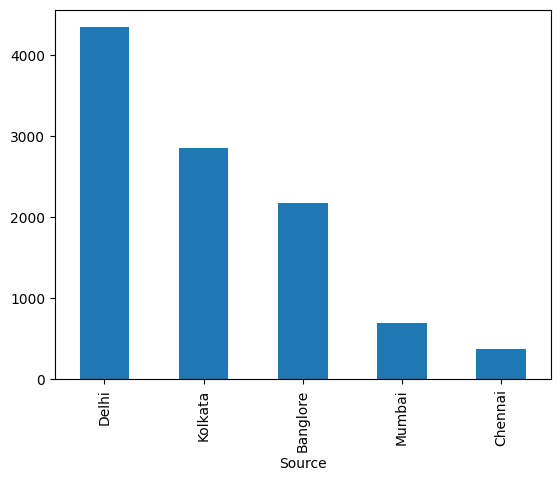

In [278]:
flight_df.Source.value_counts().plot(kind="bar")

<Axes: xlabel='Destination'>

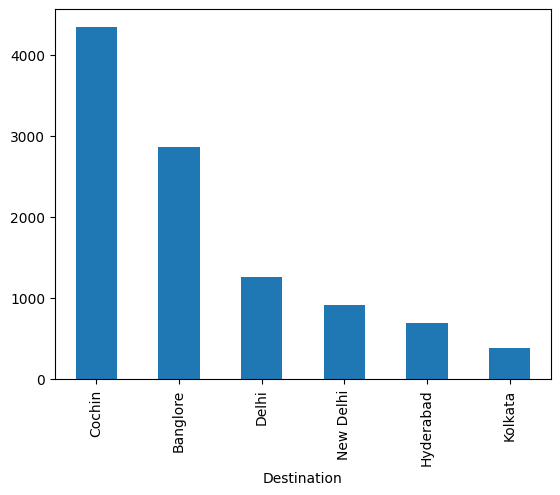

In [279]:
flight_df.Destination.value_counts().plot(kind="bar")

<Axes: xlabel='Route'>

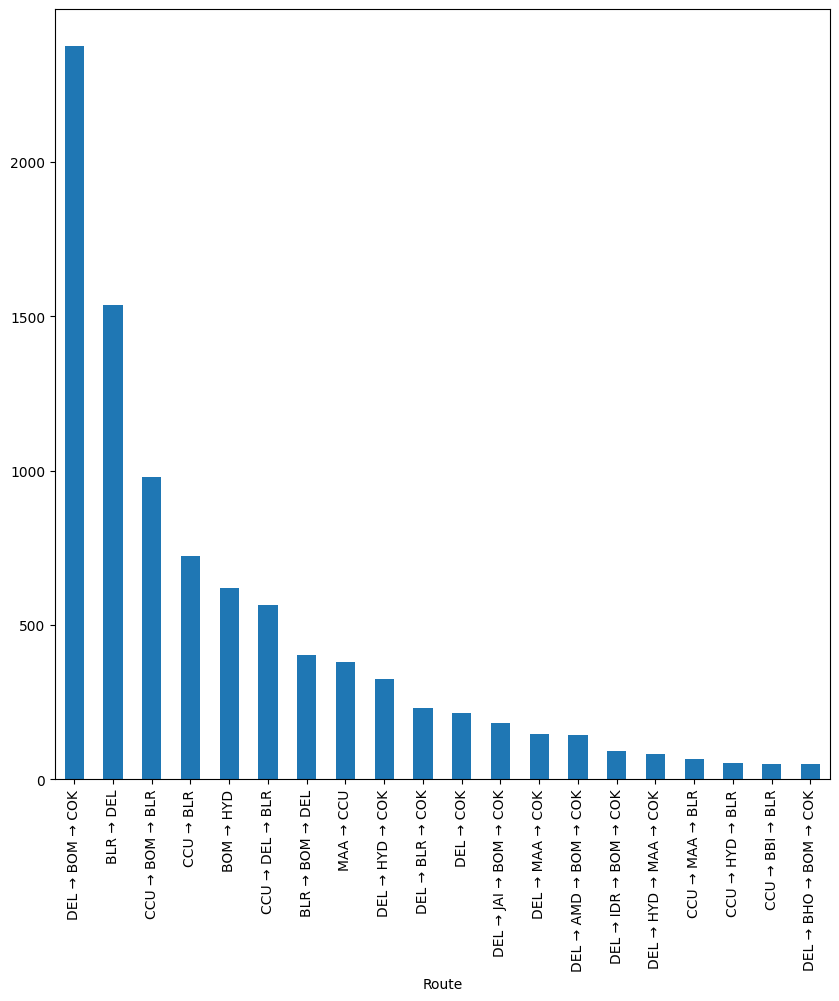

In [280]:
#viewing top 20 travelling routes

plt.figure(figsize=(10,10))
flight_df['Route'].value_counts().head(20).plot(kind='bar')

In [281]:
#dropping route feature
flight_df.drop('Route', axis=1, inplace=True)

In [282]:
#applying onehotencoding on features Airline,Source, Destination and Additional_Info

encoder = OneHotEncoder()

data=encoder.fit_transform(flight_df[['Airline', 'Source', 'Destination', 'Additional_Info']]).toarray()

df =  pd.DataFrame(data=data, columns=encoder.get_feature_names_out())
df


,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10458,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10459,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10460,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10461,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [283]:
#some cleaning and encoding of feature 'Dep_Time'

flight_df['Dep_Time_Hour']=flight_df['Dep_Time'].str.split(":").str[0].astype(int)
flight_df['Dep_Time_Min']=flight_df['Dep_Time'].str.split(":").str[1].astype(int)

In [284]:
#some cleaning and encoding of feature 'Arrival_Time'
flight_df['Arrival_Time_Hour']=flight_df['Arrival_Time'].str.split(" ").str[0].str.split(":").str[0].astype(int)
flight_df['Arrival_Time_Min']=flight_df['Arrival_Time'].str.split(" ").str[0].str.split(":").str[1].astype(int)

In [ ]:
flight_df['Duration_Hours']=flight_df['Duration'].str.split("h").str[0]
flight_df['Duration_Hours'].unique()

array(['2', '7', '19', '5', '4', '15', '21', '25', '13', '12', '26', '22',
       '23', '20', '10', '6', '11', '8', '16', '3', '27', '1', '14', '9',
       '18', '17', '24', '30', '28', '29', '37', '34', '38', '35', '36',
       '47', '33', '32', '31', '42', '39', '5m', '41', '40'], dtype=object)

In [289]:
flight_df['Duration_Min']=flight_df['Duration'].str.split("h").str[1]
flight_df['Duration_Min'].unique()

array([' 50m', ' 25m', '', ' 45m', ' 30m', ' 5m', ' 15m', ' 35m', ' 10m',
       ' 20m', ' 55m', ' 40m', nan], dtype=object)

In [296]:
flight_df[flight_df['Duration_Min'].isna()]

,Arrival_Time,Duration,Total_Stops,Price,Day,Month,Year,Dep_Time_Hour,Dep_Time_Min,Arrival_Time_Hour,Arrival_Time_Min,Duration_Hours,Duration_Min
6474,16:55,5m,2.0,17327,6,3,2019,16,50,16,55,5m,NaN


In [ ]:
#dropping above row since tflight_df.drop(

In [286]:
flight_df.drop(['Airline', 'Source', 'Destination', 'Additional_Info','Dep_Time'], inplace=True, axis=1)